In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [35]:
import sys
sys.path.append('/content/drive/MyDrive/DeepfakeProject()')

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json, os
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from dataset import DeepfakeDataset


In [96]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
!unzip -q /content/drive/MyDrive/DeepfakeProject/faces.zip

In [ ]:
train_ds = DeepfakeDataset(
    root='/content/content/faces',
    split='train',
    augment=True
)

val_ds = DeepfakeDataset(
    root='/content/content/faces',
    split='val',
    augment=False
)

test_ds = DeepfakeDataset(
    root='/content/content/faces',
    split='test',
    augment=False
)

In [103]:
train_loader = DataLoader(
    train_ds, batch_size=5,
    shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())

val_loader = DataLoader(
    val_ds, batch_size=5,
    shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Train: 700 | Val: 150


In [104]:
import importlib
import models

importlib.reload(models)

from models import build_model

In [105]:
model = build_model('transformer')
model = model.to(device)

In [106]:
NUM_EPOCHS = 20
CHECKPOINT = '/content/drive/MyDrive/DeepfakeProject/outputs/checkpoints'

In [107]:
criterion = nn.BCEWithLogitsLoss()

optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6)

In [108]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for frames, labels in loader:
        frames = frames.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(frames)


        preds = (torch.sigmoid(outputs) > 0.5).float()

        loss    = criterion(outputs, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        preds    = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / total * 100
    return avg_loss, accuracy

In [109]:
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for frames, labels in loader:
            frames  = frames.to(device)
            labels  = labels.to(device).unsqueeze(1)
            outputs = model(frames)
            loss    = criterion(outputs, labels)

            preds    = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / total * 100
    return avg_loss, accuracy

In [110]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [111]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [],
    'lr'        : []
}

best_val_acc  = 0.0
best_val_loss = float('inf')
patience      = 5
no_improve    = 0

print(f'Starting training for {NUM_EPOCHS} epochs...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | '
      f'{"Val Loss":>8} | {"Val Acc":>7} | {"LR":>8}')
print('-' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion)

    val_loss, val_acc = validate(model, val_loader, criterion)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% | '
          f'{val_loss:>8.4f} | {val_acc:>6.2f}% | {current_lr:>8.6f}')

    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_val_loss = val_loss
        no_improve    = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'val_acc'    : val_acc,
            'val_loss'   : val_loss,
            'history'    : history,
        }, f'{CHECKPOINT}/best_model.pth')
        print(f'  Best model saved (val_acc={val_acc:.2f}%)')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'\n Early stopping at epoch {epoch}')
            break

print(f'\nBest val accuracy : {best_val_acc:.2f}%')
print(f'Best val loss     : {best_val_loss:.4f}')


Starting training for 20 epochs...

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR
-----------------------------------------------------------------
     1 |     0.7097 |    51.14% |   0.6858 |  51.33% | 0.000099
  Best model saved (val_acc=51.33%)
     2 |     0.6443 |    64.43% |   0.5472 |  74.67% | 0.000098
  Best model saved (val_acc=74.67%)
     3 |     0.5049 |    80.14% |   0.6946 |  78.00% | 0.000095
  Best model saved (val_acc=78.00%)
     4 |     0.4726 |    83.86% |   0.5414 |  81.33% | 0.000091
  Best model saved (val_acc=81.33%)
     5 |     0.4503 |    85.14% |   0.9513 |  78.67% | 0.000086
     6 |     0.4559 |    86.57% |   0.8495 |  81.33% | 0.000080
     7 |     0.3977 |    86.43% |   0.7460 |  79.33% | 0.000073
     8 |     0.3483 |    89.71% |   0.7046 |  84.67% | 0.000066
  Best model saved (val_acc=84.67%)
     9 |     0.3739 |    89.29% |   0.9515 |  80.67% | 0.000058
    10 |     0.2883 |    92.86% |   0.7413 |  85.33% | 0.000051
  Best model s

In [114]:
with open(f'/content/drive/MyDrive/DeepfakeProject/outputs/results/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

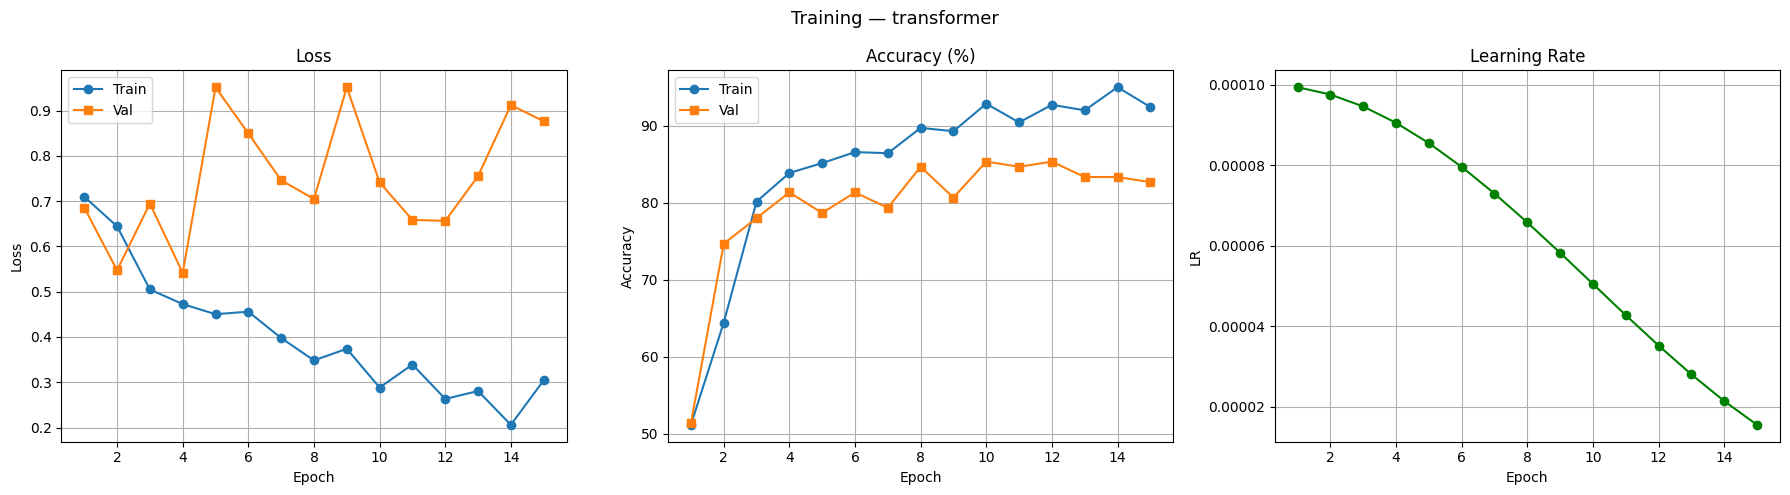

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs, history['val_loss'],   label='Val',   marker='s')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, history['train_acc'], label='Train', marker='o')
axes[1].plot(epochs, history['val_acc'],   label='Val',   marker='s')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# Learning rate
axes[2].plot(epochs, history['lr'], marker='o', color='green')
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].grid(True)

plt.suptitle(f'Training — transformer', fontsize=13)
plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/DeepfakeProject/outputs/results/training_curves.png', dpi=150)
plt.show()